In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Load the dataset
df = pd.read_csv('Employee.csv')
#Data Exploration:
# Unique values + count
for col in df.columns:
    print(f"{col} → Unique Count:", df[col].nunique())
    print(df[col].unique())


Company → Unique Count: 6
['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Age → Unique Count: 29
[20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Salary → Unique Count: 40
[  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Place → Unique Count: 11
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Country → Unique Count: 1
['India']
Gender → Unique Count: 2
[0 1]


In [ ]:
# Statistical summary
print(df.describe())
# Rename columns (standard format)
df.columns = df.columns.str.lower()
print(df.columns)

In [ ]:
#Data Cleaning
#Handle Missing Values
# relace missing company with mode
df['company'] = df['company'].fillna(df['company'].mode()[0])
# Replace Age = 0 (if any)
df['age'] = df['age'].replace(0, np.nan) 
# Fill missing Age → median
df['age'] = df['age'].fillna(df['age'].median())
# Fill Salary with mean
df['salary'] = df['salary'].fillna(df['salary'].mean())
#replace missing place with mode
df['place'] = df['place'].fillna(df['place'].mode()[0])

#Remove all duplicate rows.
df.drop_duplicates(inplace=True)

#Handle Outliers (IQR)

Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['salary'] >= Q1 - 1.5*IQR) & 
        (df['salary'] <= Q3 + 1.5*IQR)]






     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


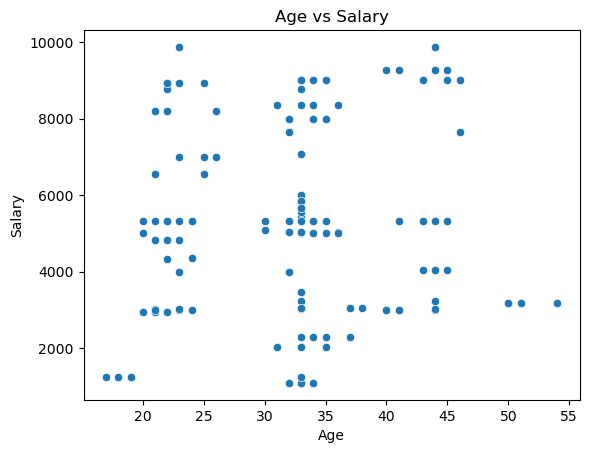

In [ ]:
#Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

filtered = df[(df['age'] > 40) & (df['salary'] < 5000)]
print(filtered)
sns.scatterplot(data=df, x='age', y='salary')
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()


place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


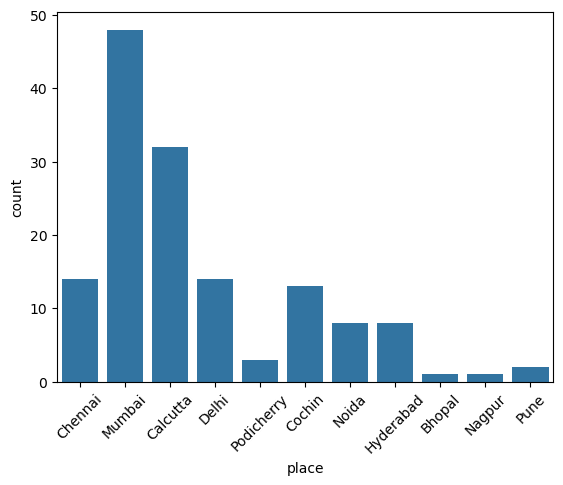

In [88]:
place_count = df['place'].value_counts()
print(place_count)
sns.countplot(data=df, x='place')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Data Encoding:
#one-hot encoding,

df_encoded = pd.get_dummies(df, columns=['company','place','country'])
print(df_encoded.head())

#label encoding,
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['company'] = le.fit_transform(df['company'])
df['place'] = le.fit_transform(df['place'])
df['country'] = le.fit_transform(df['country'])

print(df[['company','place','country']].head())

In [93]:
#Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age','salary']] = scaler.fit_transform(df[['age','salary']])

from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
df[['age','salary']] = mm.fit_transform(df[['age','salary']])